# Neural Network for CIFAR classification. Regularisation.

In this hometask you'll implement and train a neural network for classification of images of CIFAR dataset. This task is harder than MNIST, which we used in a previous hometask. In this hometask, we will also learn about two types of regularisation layers that are widely used in NNs — Dropout and BatchNorm, and you will add them to your network for CIFAR classification.

CIFAR is a dataset of RGB images containing 10 classes. Here's the list of the classes and their indices:


| Label        | Class           |
| ------------- |:-------------:|
| 0     | Airplane |
| 1    | Automobile      |
| 2 | Bird      |
| 3 | Cat      |
| 4 | Deer      |
| 5 | Dog      |
| 6 | Frog     |
| 7 | Horse     |
| 8 | Ship     |
| 9 | Truck     |



Let's also create a dictionary mapping class indices to the names. We will need it later for converting model outputs to class names.

In [ ]:
class_to_label = {
    0: 'Airplane',
    1: 'Automobile',
    2: 'Bird',
    3: 'Cat',
    4: 'Deer',
    5: 'Dog',
    6: 'Frog',
    7: 'Horse',
    8: 'Ship',
    9: 'Truck'
}

Here's how images in CIFAR look like:

![alt text](https://miro.medium.com/v2/0*BdetXYemwXwOqNTs.jpg)

## Loading data

In [ ]:
import numpy as np

import torch
from torch import nn
from torch.nn import functional as F
from tqdm.notebook import tqdm

from matplotlib import pyplot as plt
from IPython.display import clear_output

We'll use `torchvision` library to load the dataset this time.

In [ ]:
import torch
import torchvision
from torchvision import datasets, transforms

In [ ]:
train_data = datasets.CIFAR10(root="./cifar10_data", train=True, download=True, transform=transforms.ToTensor())
test_data = datasets.CIFAR10(root="./cifar10_data", train=False, download=True, transform=transforms.ToTensor())

100%|██████████| 170M/170M [00:11<00:00, 14.7MB/s]


Extracting ./cifar10_data/cifar-10-python.tar.gz to ./cifar10_data
Files already downloaded and verified


Let's also split training data into train and validation parts, so we can check metrics on validation part between training epochs

In [ ]:
# split the training sample into train and val# we will allocate 80% of all images to the training sample
train_size = int(len(train_data) * 0.8)
# the remaining 20% will go to validation
val_size = len(train_data) - train_size
# splitting the data
torch.manual_seed(42)
train_data, val_data = torch.utils.data.random_split(train_data, [train_size, val_size])

Now let's take a look at a few pictures to understand what we are dealing with

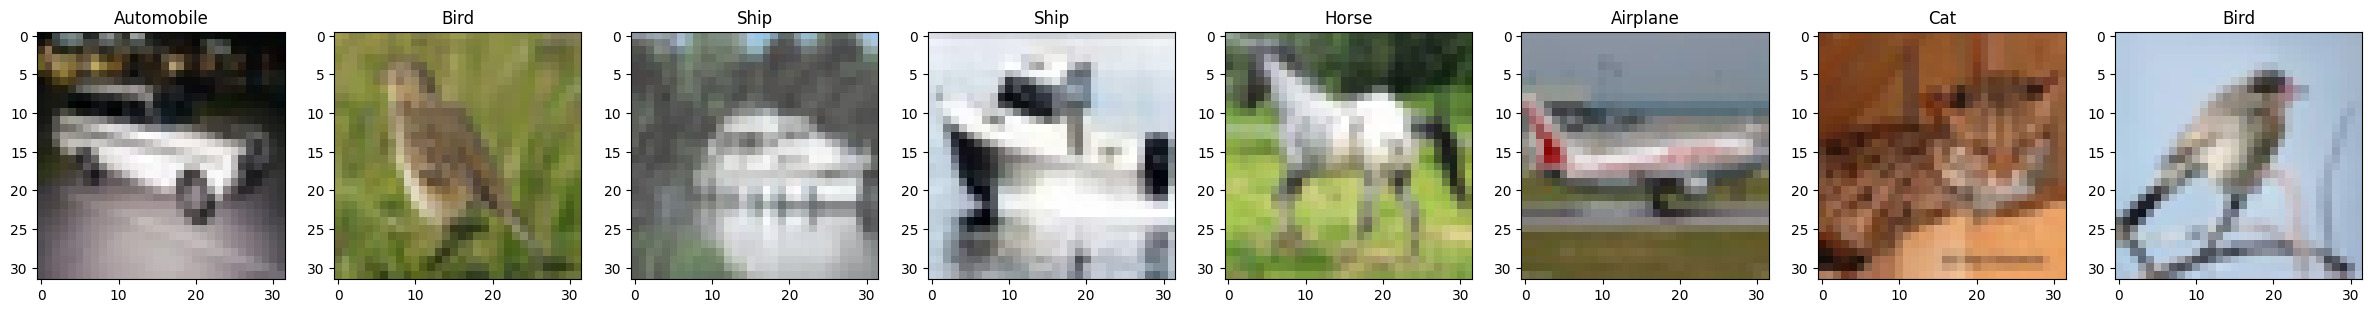

In [ ]:

# create a plot with 8 subplots to visualise 8 images
f, axes= plt.subplots(1, 8, figsize=(30,5))

for i, axis in enumerate(axes):
    # convert image from tensor to numpy
    img, label = train_data[i]
    # convert image to shape (height, width, color channels)
    img = np.transpose(img, (1, 2, 0))
    axes[i].imshow(img)
    axes[i].set_title(class_to_label[label])
plt.show()

Let's see what size the pictures are:

In [ ]:
img, label = train_data[0]
img.shape

torch.Size([3, 32, 32])

Here, 3 is the number of color channels (since the image is colored, RGB) and 32 and 32 are the width and height of the image. Thus, each image is represented by 32 * 32 * 3 = 3072 values. This means that there should be 3072 neurons in the first layer of the network for solving CIFAR classification task.

## Task 1. CIFAR classification with a fully-connected network.

We will first build and train a fully-connected network for CIFAR classification, analogous to what we did in the previous hometask. After we play with it and see how good accuracy we can get, we will talk about additional regularisation layers that we can add to our network to make it more efficient.

### Task 1.1 Write a neural network for CIFAR images classification

Write any architecture that would process CIFAR image. Think about the following:
- How many input and output neurons you network should have?
- What activation function should the last layer have?
You can start with the same architecture you used in the previous hometask and than try to find something

Note that shape of CIFAR images coming from dataloaders is (3, 32, 32), and we need to flatten images into vectors of size $3 \cdot 32 \cdot 32$ before feeding them into our model. There is a special layer in torch.nn module for this, called Flatten. If we use it as the first layer in our model, it will automatically flatten images into vectors.

In [ ]:
import torch.nn as nn

class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()

        # flatten layer
        self.flatten = nn.Flatten

        # define layers and activation function that your model will have
        # YOUR CODE HERE

    def forward(self, x):

        x = self.flatten(x)

        # define a flow of input through your layers
        # YOUR CODE HERE


        return x

And create a network:

In [ ]:
net = Net()

### Task 1.2. Define a train function.

You can borrow the code from last homework. Hovewer, we'll make one addition to the training code: we will add evaluation on validation data after each epoch. You can use the code for `evaluate` function from last homework as a base for it.

Again, it might also be beneficial to see how training loss evolves during training, this will help you do experiments later. You can either save average of losses on batches per epoch into array and return it as output of the `train` function, so you can then visualize it using [matplotlib.plot](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.plot.html). Or you can add plotting average of losses on batches per epoch inside the `train` function. In this case you might also need using a function to clear output of the cell, so you can draw new plot after each epoch. You can find how to do it [here](https://stackoverflow.com/questions/24816237/ipython-notebook-clear-cell-output-in-code)

In [ ]:
import tqdm
from tqdm.auto import tqdm

# define a function
# you can change arguments of this function if you want
def train(model, train_loader, val_loader, criterion, optimizer, num_epoch):
    '''
    args:
        model - our neural network model
        train_loader — structure which yields batches of training data
        val_loader — structure which yields batches of validation data
        criterion - loss function from `torch.nn` module
        optimizer - optimizer from `torch.optim` module
        num_epoch - number of training epochs
    '''

    for t in tqdm(range(num_epoch)):
        # training epoch
        for X, y in train_loader:
            # YOUR CODE HERE

        # validation
        for X, y in val_loader:
            # YOUR CODE HERE

And let's define loss function, optimizer, dataloader and train our network.

In [ ]:
# loss function
criterion = # YOUR CODE HERE — define a loss function (binary cross-entropy)
# optimizer
optimizer = # YOUR CODE HERE — define an optimizer and pass params of neural network to it
# dataloader
train_loader = # YOUR CODE HERE — define a train loader
val_loader = # YOUR CODE HERE — define a val loader

# run training
NN = train(NN, train_loader, val_loader, criterion, optimizer, 60)

### Task 1.3. Write a code for model evaluation

After we train our neural network, we'll need to evaluate it on test data and compute accuracy metric. Let's now define the function for it. Your task is to fill the gaps in the code below. Again, you can borrow the code from last homework.

In [ ]:
def evaluate(model, loader, criterion):
    '''
    args:
        model - our neural network model
        loader — structure which yields batches of test data
        criterion - loss function from `torch.nn` module
    '''

    # arrays for storing loss values, network predictions and true values
    losses = []
    y_pred_list = []
    y_true_list = []

    for X_batch, y_batch in loader:

        # this disables gradient computations to save time and memory
        # we don't need gradients on test data
        with torch.no_grad():
            # getting our model's predictions on current batch
            y_pred = # YOUR CODE HERE

            # calculate loss function
            loss = # YOUR CODE HERE
            losses.append(loss.item())


        # convert outputs of your network into class number
        y_pred = # YOUR CODE HERE

        # save for accuracy calculation
        y_pred_list.extend(y_pred)
        y_true_list.extend(y_batch.tolist())

    # calculate accuracy score based on y_pred_list and y_true_list
    accuracy = # YOUR CODE HERE

    return np.mean(losses), accuracy

And let's evaluate our trained network on test data.

In [ ]:
test_loader = # YOUR CODE HERE — define a test loader

evaluate(model, test_loader, criterion)

### Task 1.4. Train the neural network to classify CIFAR data

Now you have a network that can be trained and evaluated on binary classification data. Your next task is to make it better, so that your neural network can achieve as high accuracy as possible on the test part.

You are free to build any neural network architecture you want and use any hyperparameters for training. Here are some tips:
- Start with no more than 2-3 hidden layers each having 5-7 neurons
- Think about how many neurons your input and output layers should have
- What activation function do you need to use in the last layer?
- Play with number of layers, numbers of neurons in layers, different activation functions
- Try different training **hyperparameters**: learning rate, number of epochs, type of optimizer, batch size

After you've done experimenting, describe your findings. Try to answer the following questions:
- What is maximum accuracy on test test that you were able to achieve? Do you think it is possible to get higher accuracy using fully-connected network? Why?
- Have you observed overfitting? When does it start, i.e. how big the network should be?
- How does the behaviour of the model change when you change different hyperparameters?
- What interesting behaviour have you observed? What was beneficial and what did not influence the model?

Here is also a hint on experimenting: try to change one parameter at time. When you change the parameter, retrain the network and see how the behaviour has changes. Log the results, so you can then a general picture of how each parameter influences the model training. This will also help you not to forget what you have already tried.





In [ ]:
# YOUR CODE HERE

## Task 2. Adding regularisation layers

In this section we will get familiar with two powerful techniques for regularizing neural networks — Dropout and BatchNorm. First we'll review the theory, and then you will add them to your network for CIFAR classification.

Note that these techniques (or their modifications) are still used in modern neural networks such as LLMs. We will see it further in the course

### BatchNorm

Let's look at a neural network that has several layers. Note that a subnetwork starting from the $i^{th}$ layer can be seen as a sub-model, which takes outputs of the previous layer as input. We already know that it is important to normalise the input data that we feed into a model. So should we also normalise inputs to hidden layers?

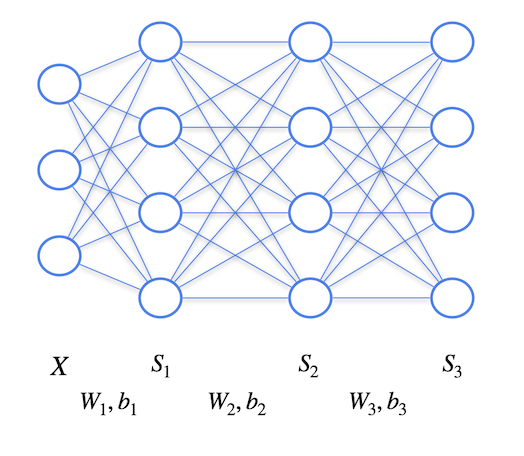

It seems thatwould  normalizing the outputs of each intermediate layer also contribute to more efficient training of the network. And **BatchNorm is the layer that performs such normalization**.

**How does it do that?** The first idea that comes to mind is to do the same thing as with input normalization: let's normalise the output of each neuron so that it has a mean=0 and std=1 across the training data.

But this idea has two issues:
1. In order to shift outputs of each neuron so that thay have fixed mean and std across all the training data, we would first need to calculate each neuron's outputs on all the objects from the training data. This is computationally infeasible.
2. Instead of fixing mean and std of outputs, why not let neural network during training decide itself how it is better to normalise outputs of each layer?  

How to address these two issues? Here are couple of ideas:
1. We may approximate statistics (mean and std) of neuron outputs based on mini-batch data, not based on all the training data.
2. We can introduce trainable parameters that will adjust mean and std of layers' neurons.

BatchNorm is a technique of layer output normalisation that uses these two ideas. **BatchNorm is a trainable layer that normalizes the outputs of the network using trainable parameters**.

So here is what BatchNorm does:

Suppose we have a layer. On a mini-batch training iteration the layer has $b$ outputs $\{x_i\}_{i=1}^b$.

1. Calculate mean $\mu_B$ and std $\sigma_B$ of the layer outputs on a current batch:
$$\mu_B = \frac{\sum_{i=1}^b x_i}{b}$$
$$\sigma^2_B = \frac{\sum_{i=1}^b (x_i - \mu_B)^2}{b}$$
2. Normalise layer outputs using $\mu_B$ and $\sigma_B$:
$$\widehat{x}_i = \frac{x_i - \mu_B}{\sigma_B+ \epsilon}$$
3. Calculate modified layer outputs as follows:
$$y_i = \gamma \widehat{x}_i + \beta$$

Here $\gamma$ and $\beta$ are trainable parameters.

So here happens the following:

* First, on steps 1-2, layer outputs are normalized so that each neuron has mean value of 0 and standard deviation of 1 across elements of the batch.
* Then, on step 3, means and standard deviations of each neuron are shifted by $\beta$ and $\gamma$ respectively. Both $\beta$ and $\gamma$ are trainable parameters, which means that during training the neural network is allowed to adjust mean and standard deviation of layer's outputs. $\beta$ and $\gamma$ are trained together with all the model parameters during gradient descent.



    


So we have described what BatchNorm does during training. **Now let's think about inference.** Here we have one problem: during inference, we want to be able to get the output of a model for a single object, i.e. we can have batch size equal to 1. On step 1 of our BatchNorm algorithm, we calculated mean and std estimates across current batch of data, and if we have only one element in the batch, we can't get reliable mean and std estimates for neurons' outputs.

So what shall we do? The idea is the following: let's gather the statistics of mean and std values calculated for mini-batches during training. And then we will use this statistics during inference. Actually, this aligns with how we normalise input data: during inference we use statistics calculated on the training data to normalise the test data.

So we will need to add one step to the BatchNorm algorithm during training:

Before training, define veriables
$$\mu_r= 0$$
$$\sigma_r = 0$$
We also fix a number $momentum\in[0,1]$. We'll see what it does in a second.

Now, for every batch:
1. Calculate mean $\mu_B$ and std $\sigma_B$ of the layer outputs on the current batch:
$$\mu_B = \frac{\sum_{i=1}^b x_i}{b}$$
$$\sigma^2_B = \frac{\sum_{i=1}^b (x_i - \mu_B)^2}{b}$$
2. Update $\mu_r$ and $\sigma_r$:
$$\mu_r = (1 - momentum)\cdot\mu_r + momentum \cdot \mu_B$$
$$\sigma_r = (1 - momentum)\cdot\sigma_r + momentum \cdot \sigma_B$$
(These are *exponential moving averages*.)
3. Normalise layer outputs using $\mu_B$ and $\sigma_B$:
$$\widehat{x}_i = \frac{x_i - \mu_B}{\sigma_B+ \epsilon}$$
4. Calculate modified layer outputs as follows:
$$y_i = \gamma \widehat{x}_i + \beta$$


And during inference, BatchNorm layer will perform the following. Suppose we have a layer output $x_i$.
1. Normalise outputs of the layer using $\mu_r$ and $\sigma_r$:
$$\widehat{x}_i = \frac{x_i - \mu_r}{\sigma_r + \epsilon}$$
2. Calculate modified layer outputs as follows:
$$y_i = \gamma \widehat{x}_i + \beta$$




So this is the whole thing about BatchNorm. BatchNorm really does stabilise and accelerate training. Here is a figure from original paper on BatchNorm, showing performance of the same neural network without BatchNorm and with BatchNorm added in different ways. We see that versions of the model with BatchNorm are able to achieve the same accuracy as model without BatchNorm after much smaller amount of training steps.

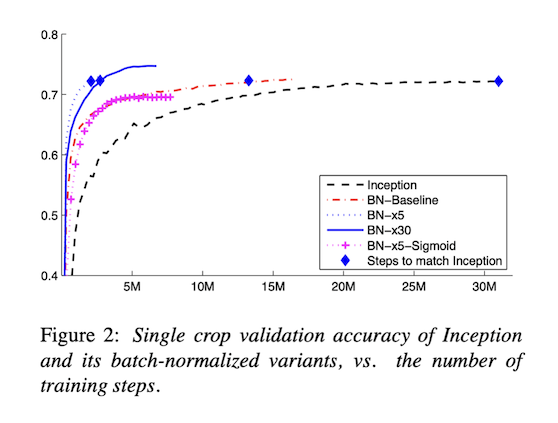

One more thing on BatchNorm before you will add it to your neural network for CIFAR classification: BatchNorm is also believed to help with the **internal covariate shift** in neural networks.

What is internal covariate shift: Each layer of the network during training must adjust to the values that the previous layer produces. During network training, the distributions of values ​​that each layer of the network produces change. And each hidden layer at each iteration of the algorithm has to adjust to the new distribution of the outputs of the previous layer. This makes training process less effective, it slows down the convergence.

BatchNorm should help with this problem, as it stabilises the distributions of layers outputs. However, the fact that BatchNorm has something to do with internal covariate shift is not proved.

Note, however, that **you will not need to do these computations during training or inference when building neural network with PyTorch**. All this behaviour is implemented inside BatchNorm layer. You need just to add it to your neural network!

### Task 2.1 Add BatchNorm to your network

**Now to the practical part:**

BatchNorm layer in PyTorch is defined as [torch.nn.BatchNorm1d](https://pytorch.org/docs/stable/generated/torch.nn.BatchNorm1d.html). Your task is to add this layer after one or more hidden layers in your network for CIFAR classification. Experiment with where to add BatchNorm. Maybe you'll need to modify an architecture of you network to achieve better results, but start with the architecture you've built in the Task 1.

Try to answer the following questions:
- How does the performance of your network change when adding BatchNorm? Is it able to achieve better accuracy on validation/test data than without BatchNorm?
- Is your network able to achieve same accuracy in smaller amount of training iterations?
- Are you able to build a bigger model with BatchNorm and not get overfitting?
- Does optimal network architecture with BatchNorm differ from that of without BatchNorm?

In [ ]:
# YOUR CODE HERE

There's one more thing you need to know: as we've seen, behaviour of BatchNorm is slightly different during training and during inference. Indeed, we calculate $\mu_B$ and $\sigma_B$ based on current mini-batch suring training, and we use pre-calculated $\mu_r$ and $\sigma_r$ on inference. So we need to switch between these two regimes when training and evaluating our network.

It is done using `.train()` and `.eval()` methods as follows:

In [ ]:
# turns on the training mode for all model layers
model.train()
# turns on the inference mode for all model layers
model.eval()

So we'll need to add this to our training function:

In [ ]:
import tqdm
from tqdm.auto import tqdm

# define a function
# you can change arguments of this function if you want
def train(model, train_loader, val_loader, criterion, optimizer, num_epoch):
    '''
    args:
        model - our neural network model
        train_loader — structure which yields batches of training data
        val_loader — structure which yields batches of validation data
        criterion - loss function from `torch.nn` module
        optimizer - optimizer from `torch.optim` module
        num_epoch - number of training epochs
    '''

    for t in tqdm(range(num_epoch)):
        # switching to training mode
        model.train()
        # training epoch
        for X, y in train_loader:
            # YOUR CODE HERE

        # switching to evaluation mode
        model.eval()
        # validation
        for X, y in val_loader:
            # YOUR CODE HERE

Also don't forget to turn on `eval` mode when testing your model! Or you can add `model.eval()` inside the evaluation function.

### Dropout

Dropout is another powerful technique that helps make training more efficient and reduce overfitting.

Dropout can be seen as adaptation of model ensembling technique to neural networks. Let us remind ourselves first, what model ensembling is.

Model ensembling is one of the most powerful techniques in machine learning, while being really simple. The idea is to train not one, but several models for the same task on the same training data, and then average their predictions during inference. If all of the trained models are good enough in solving the task, then averaging their predictions will lead to better performance on the task than that of each individual model. It's a little tricky what "model is good enough on the task" and "better performance on the task" mean, but here's an example: if we solve the task of binary classification, "good enough" could mean that every model in the ensemble gets accuracy > 0.5 on the test data.

Intuitively, the power of ensembling can be seen as follows: models in an ensemble make mistakes on different data samples, and averaging model predictions smoothes these mistakes, i.e. one model compensates mistakes made by another model.

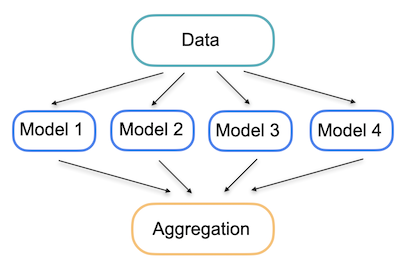

It is also important that models in an ensemble should be diverse enough. (You've already seen this when you discussed self-consistency.) That is logical: there is no point in averaging predictions of similar models, as they make the same mistakes on the same samples. To ensure diversity of models in an ensemble, [bootstrapping](https://en.wikipedia.org/wiki/Bootstrapping_(statistics)) of training data is often used. Ideas of bootstrapping combined with emsembling leads to the well-known idea of **[Bagging](https://en.wikipedia.org/wiki/Bootstrap_aggregating)** (**B**ootstrap **Agg**regating). We will not further dive into bootstrapping or bagging here, but we encourage you to read about it.

So if ensembling is such a powerful technique, then **can we apply ensembling to neural networks as well**, can't we? Well, we can, but averaging predictions of many trained neural networks is costly. First, we would need to train many neural networks for the same task, and this would require much computational recourses and time. Second, this would slow down the inference and make it more costly as well, as we would need to get predictions from many models for each input object.

**Dropout is a technique that imitates ensembling of neural networks using only one neural network.**



The idea is the following: before training, let's choose a value of $p \in [0, 1]$. Then, during training, on each mini-batch we will "turn off" each neuron in our network with probability $p$. "Turning off" means that this neuron will not participate in forward pass og the network. Or it can be seen as neuron that is "turned off" outputting zero on a current mini-batch.

This can be visualised as follows:

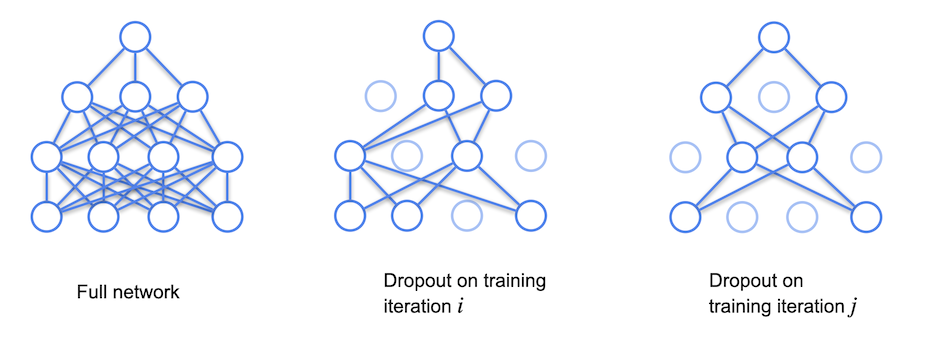

In code, "turning off" neurons in the layer can be done via simple masking. So if we apply Dropout to ф fully-connected layer, we first calculate all the neurons' outputs as usual. Then we sample a mask of zeros and ones, and each element of the mask is zero with probability $p$. After that we multiply layer output with the mask in an element-wise manner. Here is the illustration of the process:

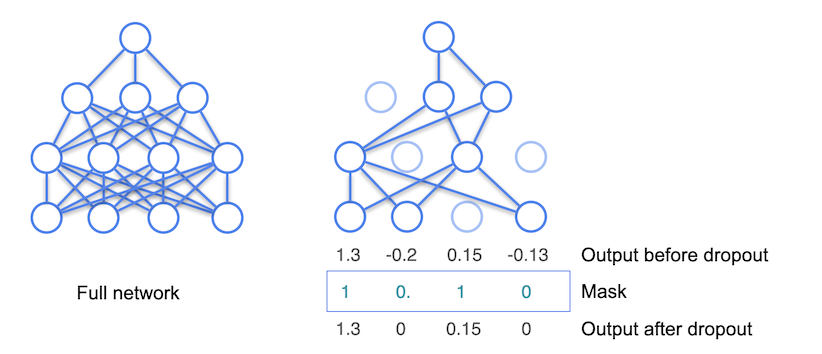

**What are the benefits of Dropout and how it is connected to ensembling:**

When using Dropout, we train a slightly different neural network (a subnetwork of the whole model) on each training iteration. This can be seen as training many different models on the same training data, outputs of which will then be aggregated on inference. However, there are differences between vanilla ensembling and Dropout:
- Each subnetwork is trained on a tiny fraction of data (mini-batch), and only for one iteration. In canonical ensembling, each models is trained on its training data until convergence
- All the subnetworks share weights, i.e. they are all parts of one whole model. In canonical ensembling all the models are completely independent
- Using Dropout, we can have exponential number of subnetworks, while in canonical ensembling there are normally 10-20 models in total

Beside this, Dropout has a nice regularisation effect on a neural network — it helps reduce overfitting. To better understand this, let's assume we've applied dropout to the layer of the network. And let's now consider one of the neurons in the subsequent layer of the network:

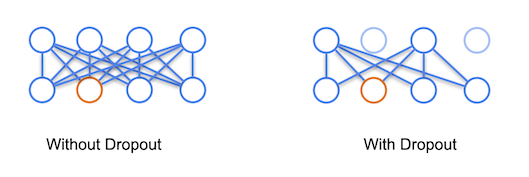

If we were not using dropout, this neron could overfit to specific information coming from the previous layer. So the previous layer has 4 neurons, and our orange neuron gets information from all of them. It might happen that during training this orange neuron learns to rely only on the information coming from only one of these 4 neurons from the previous layer; let's say the leftmost neuron. This might be expressed by the weight between the left neuron of the previous layer and our orange neuron being big, and other weights being small. This would mean that our orange neuron heavily relies on the information coming from only one neuron of the previous layer.

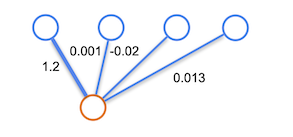

This would mean that our orange neuron has overfitted on the specific information coming from one particular neuron of the previous layer. And decision of orange neuron will be extremely bad in cases when output of this neuron of the previous layer is corrupted, or out-of-distrubution.

We can look at it from the following perspective: each neuron in the network reacts to the specific information present on the input object. If we are solving face recognition problem, a neuron might, for exmaple, extract information about some aspect of person's face, e.g. nose. It might happen that in the training data, there were only images of people's faces with noses visible, but in test data we can get an image of a person in a mask. In this case, the output of the neuron reacting to noses will be non-informative, or corrupted. And if our orange neuron relies heavily on the information coming from that neuron, it won't be able to produce meaningful output, too.

When using Dropout, we sometimes break the connection between the orange and each of the neurons in the previous layer. This makes our orange neuron produce meaningful output based on different combinatioins of features coming from previous layer. So if one of these features becomes corrupted, our neuron will still be able to generate meaningful output based on other features coming from different neurons of the previous layer.

To sum up, training with dropout makes neurons be able to perform well regardless of which other hidden units are in the model. It prevents units from forming “distinct pattern ways”, makes each unit be able to work with different input patterns. **This makes model more robust to unusual data perturbations and reduces overfitting**.


Ok, we've understood how to use Dropout during training and what benefits it provides. Now let's see **how to perform Dropout during inference**.

If we follow idea of ensembling, we should average predictions of all the models in our ensemble. But we can't do that, as we have sampled a new model on each training iteration. We could probably sample 10-20 such models (i.e. sample 10-20 versions of network with Dropout) and average their predictions on test data, but this is still costly.

Instead of doing actual ensembing, we will do the following: let's just disable Dropout during inference. But if we simply do that, this will change the expected value coming to neuron of the next layer. Imagine a neuron connected to 4 neurons of the previous layer. If we used Dropout with $p=0.5$ during training, this neuron got used to getting about half of the outputs of previous layer's neurons. If we simply disable Dropout on inference, this neuron will suddenly start getting two times more outputs, which can break its behaviour.

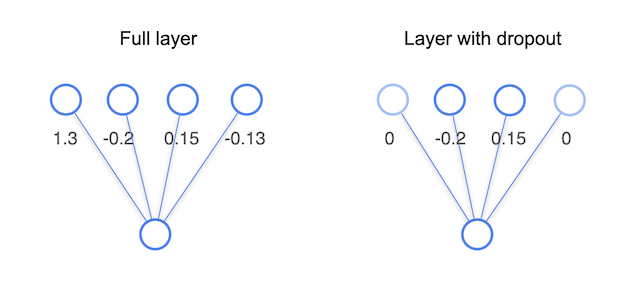

Let's compensate this. First, let's reformulate the problem: we said that the expected input value of neuron of the next layer changes if we disable Dropout. It can also be seen from another perspective: expected value of output of each neuron on the layer with Dropout changes when we disable Dropout. Indeed, each neuron's output was zeroed with probability $p$ during training, and now it is never zeroed, meaning the expected value has risen by fraction of $\frac{1}{p}$. So let's fix this. We can do it by simply multipying outputs of each neuron in the layer by $p$ during inference:

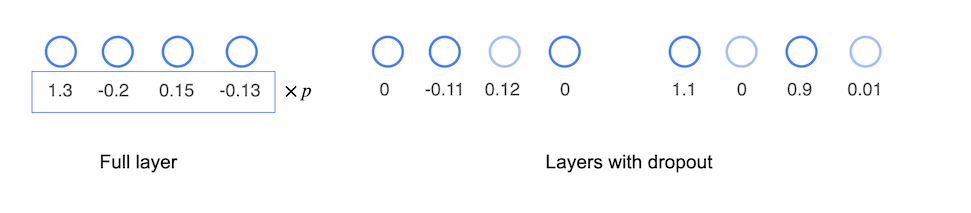

This will fix the expected value of output of each neuron during inference. In practice, however, it is more efficient to multiply outputs of neurons by $\frac{1}{p}$ during training instead. This will save time on inference, as we will not need to do another multiplication.

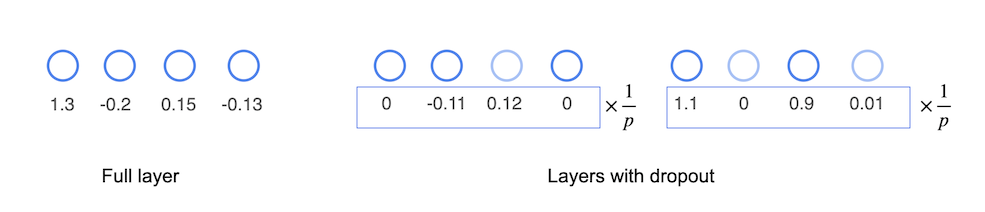

Note, however, that **you will not need to multiply anything during training or inference when building neural network with PyTorch**. All this behaviour is implemented inside Dropout layer. You need just to add it to your neural network!

So that's it! Now let's switch to practice, and add Dropout to our neural network!

### Task 2.2 Add Dropout to your network

**Now to the practical part:**

BatchNorm layer in PyTorch is defined as [torch.nn.Dropout](https://pytorch.org/docs/stable/generated/torch.nn.Dropout.html). Your task is to add this layer after one ore more hidden layers in your network for CIFAR classification. Experiment with where to add Dropout and what $p$ to choose. Maybe you'll need to modify an architecture of you network to achieve better results, but start with the architecture you've built in the Tasks 1 and 2. Try to use Dropout without BatchNorm, and then try to use Dropout with BatchNorm.

Try to answer the following questions:
- How does the performance of your network change when adding Dropout? Is it able to achieve better accuracy on validation/test data than without Dropout?
- Is it beneficial to use both Dropout and BatchNorm?
- Are you able to build a bigger model with Dropout and not get overfitting?
- What values of $p$ are optimal?
- Does optimal network architecture with BatchNorm differ from that of without BatchNorm?

**Don't forget to use `model.train()` and `model.eval()`**, as behaviour of Dropout also changes between train and inference.